In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm  # 导入颜色映射
#mpl工具里面的轴分割
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import multivariate_normal
from scipy.stats import norm
#3d绘图,现在不需要了
from mpl_toolkits.mplot3d import axes3d
from matplotlib.patches import Rectangle

In [3]:
rho     = 0.5  # 设置相关系数
sigma_X = 1    # 设置 X 的标准差
sigma_Y = 1.5  # 设置 Y 的标准差

mu_X = 0  # 设置 X 的均值
mu_Y = 0  # 设置 Y 的均值

width = 3  # 设置绘图范围

mu    = [mu_X, mu_Y]  # 定义均值向量
Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho],  # 定义协方差矩阵
        [sigma_X*sigma_Y*rho, sigma_Y**2]]

In [4]:
X = np.linspace(-width,width,101)  # 创建 X 的线性空间
Y = np.linspace(-width,width,101)  # 创建 Y 的线性空间

XX, YY = np.meshgrid(X, Y)  # 创建网格数据

XXYY = np.dstack((XX, YY))  # 组合 X 和 Y 的网格
bi_norm = multivariate_normal(mu, Sigma)  # 创建二维正态分布对象

f_X_Y_joint = bi_norm.pdf(XXYY)  # 计算联合分布的概率密度

In [5]:
E_Y_given_X = mu_Y + rho*sigma_Y/sigma_X*(X - mu_X)  # 计算 Y 在给定 X 下的条件期望

E_X_given_Y = mu_X + rho*sigma_X/sigma_Y*(Y - mu_Y)  # 计算 X 在给定 Y 下的条件期望

theta = 1/2*np.arctan(2*rho*sigma_X*sigma_Y/(sigma_X**2 - sigma_Y**2))  # 计算角度
k = np.tan(theta)  # 计算斜率

axis_minor = mu_Y + k*(X - mu_X)  # 计算次轴
axis_major = mu_Y - 1/k*(X - mu_X)  # 计算主轴

(-3.0, 3.0)

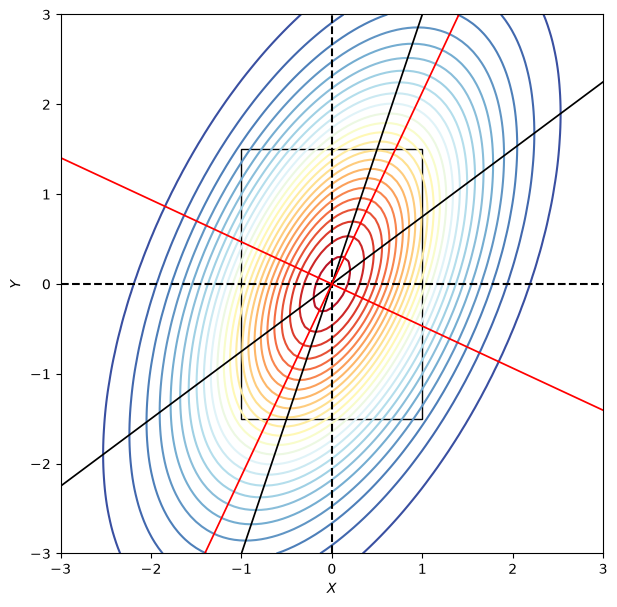

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))  # 创建图形和坐标轴

plt.contour(XX, YY, f_X_Y_joint, 25, cmap=cm.RdYlBu_r)  # 绘制联合分布等高线图
plt.axvline(x = mu_X, color = 'k', linestyle = '--')  # 绘制 X 轴参考线
plt.axhline(y = mu_Y, color = 'k', linestyle = '--')  # 绘制 Y 轴参考线

plt.plot(E_X_given_Y,Y, color = 'k', linewidth = 1.25)  # 绘制 X 给定 Y 的条件期望
plt.plot(X,E_Y_given_X, color = 'k', linewidth = 1.25)  # 绘制 Y 给定 X 的条件期望

## 绘制椭圆的主轴和次轴

plt.plot(X,axis_minor, color = 'r', linewidth = 1.25)  # 绘制次轴
plt.plot(X,axis_major, color = 'r', linewidth = 1.25)  # 绘制主轴

rect = Rectangle(xy = [mu_X - sigma_X, mu_Y - sigma_Y] , 
                 width = 2*sigma_X, 
                 height = 2*sigma_Y,
                 edgecolor = 'k',facecolor="none")  # 创建矩形边界框

ax.add_patch(rect)  # 添加矩形到图形上

ax.set_xlabel('$X$')  # 设置 X 轴标签
ax.set_ylabel('$Y$')  # 设置 Y 轴标签
ax.set_xlim(-width,width)  # 设置 X 轴范围
ax.set_ylim(-width,width)  # 设置 Y 轴范围

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
#2D仿射变换
from matplotlib.transforms import Affine2D

In [8]:
x = np.linspace(-4,4,num = 201)  # 创建 x 的线性空间
y = np.linspace(-4,4,num = 201)  # 创建 y 的线性空间
sigma_X = 1  # 设置 X 的标准差
sigma_Y = 2  # 设置 Y 的标准差

xx,yy = np.meshgrid(x,y)  # 创建网格数据

RHOs = np.linspace(-0.8,0.8,num = 9)  # 生成不同的相关系数值

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_7163/151562373.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  axis_major = - 1/k*X  # 计算主轴
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_7163/151562373.py:43: RuntimeWarning: invalid value encountered in multiply
  axis_major = - 1/k*X  # 计算主轴


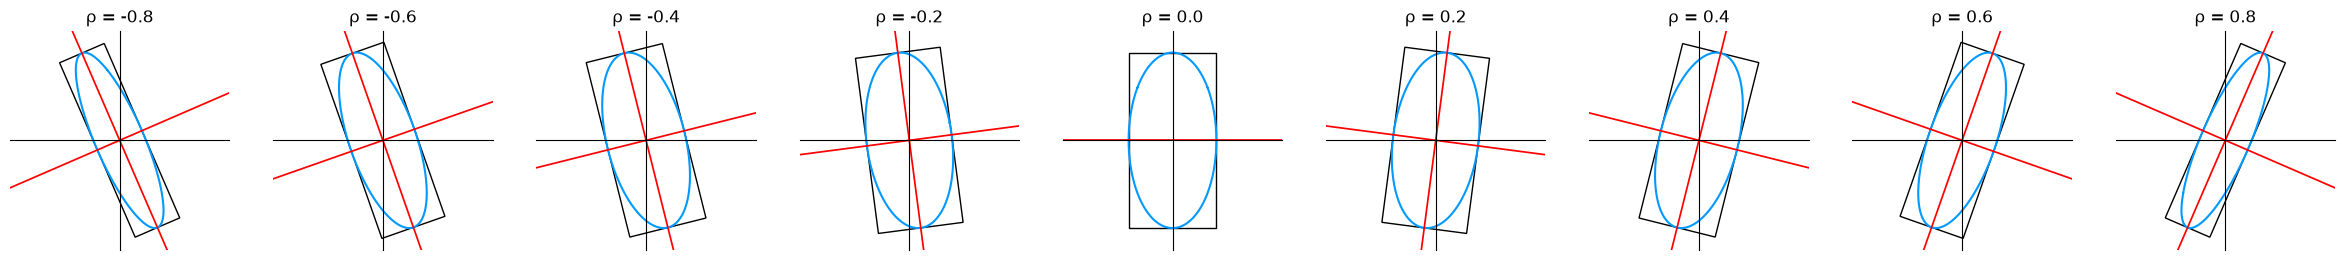

In [9]:
fig = plt.figure(figsize=(30,5))  # 设置图形尺寸

for i in range(0,len(RHOs)):
    
    rho = RHOs[i]  # 选择当前的相关系数值
    ax = fig.add_subplot(1,len(RHOs),int(i+1))  # 创建子图
    ellipse = ((xx/sigma_X)**2 - 2*rho*(xx/sigma_X)*(yy/sigma_Y) + (yy/sigma_Y)**2)/(1 - rho**2)  # 计算椭圆轮廓
    
    plt.contour(xx,yy,ellipse,levels = [1], colors = '#0099FF')  # 绘制椭圆轮廓线

    A = (sigma_X**2 + sigma_Y**2)/2  # 计算中间变量A
    B = np.sqrt((rho*sigma_X*sigma_Y)**2 + ((sigma_X**2 - sigma_Y**2)/2)**2)  # 计算中间变量B
    length_major = np.sqrt(A + B)  # 计算主轴长度
    length_minor = np.sqrt(A - B)  # 计算次轴长度
    
    if sigma_X == sigma_Y and rho >= 0:  # 判断当X和Y方差相等且相关系数非负时的角度
        theta = 45

    elif sigma_X == sigma_Y and rho < 0:  # 判断当X和Y方差相等且相关系数负数时的角度
        theta = -45
    else:
        theta = 1/2*np.arctan(2*rho*sigma_X*sigma_Y/(sigma_X**2 - sigma_Y**2))  # 计算旋转角度
        theta = theta*180/np.pi  # 将角度转换为度数
    
    if sigma_X >= sigma_Y:  # 判断并绘制主轴和次轴的方向
        rect = Rectangle([-length_major, -length_minor] , 
                         width = 2*length_major, 
                         height = 2*length_minor,
                         edgecolor = 'k',facecolor="none",
                         transform=Affine2D().rotate_deg_around(*(0,0), theta)+ax.transData)
    else:
        rect = Rectangle([-length_minor, -length_major] , 
                         width = 2*length_minor, 
                         height = 2*length_major,
                         edgecolor = 'k',facecolor="none",
                         #3个参数,*解包了,0,0是x,y,表示旋转中心
                         #出来的数据用+(运算重载符)旋转数据+投影位置 把数据安置在像素坐标里面(投影)
                         transform=Affine2D().rotate_deg_around(*(0,0), theta)+ax.transData)
    
    ax.add_patch(rect)  # 添加矩形到子图中

    X = np.linspace(-2.5,2.5,101)  # 创建 X 的线性空间
    k = np.tan(theta/180*np.pi)  # 计算旋转角度的斜率
    axis_minor = k*X  # 计算次轴
    axis_major = - 1/k*X  # 计算主轴
    plt.plot(X,axis_minor, color = 'r', linewidth = 1.25)  # 绘制次轴
    plt.plot(X,axis_major, color = 'r', linewidth = 1.25)  # 绘制主轴

    ax.set_xlim([-2.5,2.5])  # 设置 X 轴范围
    ax.set_ylim([-2.5,2.5])  # 设置 Y 轴范围
    ax.set_xticks([])  # 隐藏 X 轴刻度
    ax.set_yticks([])  # 隐藏 Y 轴刻度
    ax.spines['left'].set_position('zero')  # 设置左侧轴位置
    ax.spines['right'].set_color('none')  # 隐藏右侧轴
    ax.spines['top'].set_position('zero')  # 设置上侧轴位置
    ax.spines['bottom'].set_color('none')  # 隐藏下侧轴
    plt.gca().set_aspect('equal', adjustable='box')  # 设置图形比例
    ax.set_title('\u03C1 = %0.1f' %rho)  # 设置标题
